# Notebook 06 — Red Neuronal Multicapa (MLP)
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 6 — MLP**

Núcleo técnico del proyecto. Cada decisión de arquitectura está justificada
en función del problema médico que resolvemos.

Contenido:
- 6.1 Carga de artefactos y split interno de validación
- 6.2 Arquitectura y justificación de cada decisión
- 6.3 Diagrama visual de la red
- 6.4 Entrenamiento con callbacks
- 6.5 Curvas de entrenamiento + evolución del learning rate
- 6.6 Ajuste de umbral sobre validación
- 6.7 Comparación MLP vs mejor modelo clásico (en validación)
- 6.8 Guardado de artefactos

**Carga:** `data/processed/` (arrays numpy + meta.json)
**Genera:** `models/mlp_best.keras`, probabilidades y umbral óptimo

---
## Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

RANDOM_STATE = 42
VAL_SIZE     = 0.15
tf.random.set_seed(RANDOM_STATE)

ROOT      = os.path.abspath('..')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')
MODELS    = os.path.join(ROOT, 'models')
OUT_FIGS  = os.path.join(ROOT, 'outputs', 'figures')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


---
## 6.1 Carga de artefactos y split interno de validación

In [2]:
X_train_full = np.load(os.path.join(DATA_PROC, 'X_train.npy'))
X_test       = np.load(os.path.join(DATA_PROC, 'X_test.npy'))
y_train_full = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test       = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)

CLASS_WEIGHT_DICT = {int(k): v for k, v in meta['class_weight'].items()}
ORACLE_AUC        = meta['oracle_auc']
N_FEATURES        = meta['n_features']

# Split interno: 85% entrenamiento MLP / 15% validación de callbacks y umbral
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VAL_SIZE,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print(f"MLP train: {X_tr.shape[0]:,}  |  val: {X_val.shape[0]:,}  |  test: {X_test.shape[0]:,}")
print(f"Prevalencia val: {y_val.mean():.4f}  (debe ser ~0.1929)")
print(f"Dimensión de entrada: {N_FEATURES} features")

MLP train: 34,000  |  val: 6,000  |  test: 10,001
Prevalencia val: 0.1928  (debe ser ~0.1929)
Dimensión de entrada: 49 features


---
## 6.2 Arquitectura y justificación

| Decisión | Valor | Justificación |
|---|---|---|
| Capas ocultas | 3 | Requerido por enunciado; suficiente para tabular data |
| Neuronas | 128 → 64 → 32 | Reducción progresiva: extracción jerárquica de features |
| Activación | ReLU | Evita vanishing gradient; estándar en capas ocultas |
| BatchNormalization | Antes de activación | Estabiliza gradientes, permite lr más alta |
| Dropout | 0.30 → 0.25 → 0.20 | Más regularización en capas más anchas |
| Regularización L2 | 1e-4 (capas 1 y 2) | Penaliza pesos grandes; complementa el Dropout |
| Salida | Sigmoid | Clasificación binaria: probabilidad en [0,1] |
| Optimizador | Adam lr=1e-3 | Adaptativo, robusto a la elección inicial de lr |

In [3]:
def build_mlp(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,), name='entrada')

    # Capa 1
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4),
                     name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.30, name='dropout_1')(x)

    # Capa 2
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.25, name='dropout_2')(x)

    # Capa 3
    x = layers.Dense(32, name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Dropout(0.20, name='dropout_3')(x)

    # Salida
    outputs = layers.Dense(1, activation='sigmoid', name='salida')(x)

    model = tf.keras.Model(inputs, outputs, name='MLP_Cancer')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

mlp = build_mlp(N_FEATURES)
mlp.summary()
total_params = mlp.count_params()
print(f"\nParámetros totales: {total_params:,}")

Model: "MLP_Cancer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 448 (1.75 KB)


Parámetros totales: 17,665


---
## 6.3 Diagrama visual de la arquitectura

Exportamos el diagrama de capas directamente desde Keras.
Útil para la diapositiva 3 del entregable.

In [4]:
import io, sys

arch_path = os.path.join(OUT_FIGS, '15_mlp_architecture.png')
try:
    # Suprimir warnings de graphviz que no afectan al resultado
    _buf = io.StringIO()
    _old_stdout, _old_stderr = sys.stdout, sys.stderr
    sys.stdout = sys.stderr = _buf
    tf.keras.utils.plot_model(
        mlp, to_file=arch_path,
        show_shapes=True, show_layer_names=True,
        show_layer_activations=True, dpi=120, rankdir='TB',
    )
    sys.stdout, sys.stderr = _old_stdout, _old_stderr
    if os.path.exists(arch_path):
        print(f"Diagrama guardado: {arch_path}")
    else:
        print("plot_model no genero el archivo. Construir diagrama manualmente para las slides.")
except Exception as e:
    sys.stdout, sys.stderr = _old_stdout, _old_stderr
    print(f"plot_model no disponible ({type(e).__name__}). Construir diagrama manualmente.")

plot_model no genero el archivo. Construir diagrama manualmente para las slides.


---
## 6.4 Entrenamiento con callbacks

- **EarlyStopping** (patience=12): detiene cuando val_auc deja de mejorar
- **ReduceLROnPlateau** (factor=0.5, patience=6): reduce lr a la mitad al estancarse
- **ModelCheckpoint**: guarda los pesos de la mejor época automáticamente

In [5]:
lr_history = []   # para registrar el lr en cada época

class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        lr_history.append(lr)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=12,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=6,
                     min_lr=1e-6, mode='max', verbose=1),
    ModelCheckpoint(os.path.join(MODELS, 'mlp_best.keras'),
                    monitor='val_auc', save_best_only=True,
                    mode='max', verbose=0),
    LRLogger(),
]

history = mlp.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=512,
    class_weight=CLASS_WEIGHT_DICT,
    callbacks=callbacks,
    verbose=0,
)

best_epoch  = int(np.argmax(history.history['val_auc'])) + 1
total_epochs = len(history.history['loss'])
best_val_auc = max(history.history['val_auc'])

print(f"\nEntrenamiento completado.")
print(f"  Epocas totales:  {total_epochs}  (maximo: 200)")
print(f"  Mejor epoca:     {best_epoch}")
print(f"  Mejor val_auc:   {best_val_auc:.4f}")
print(f"  % del Oracle:    {100*best_val_auc/ORACLE_AUC:.1f}%")


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 9.

Entrenamiento completado.
  Epocas totales:  21  (maximo: 200)
  Mejor epoca:     9
  Mejor val_auc:   0.8307
  % del Oracle:    99.7%


---
## 6.5 Curvas de entrenamiento + evolución del learning rate

Tres paneles: pérdida, AUC y learning rate por época.
Permiten diagnosticar overfitting, underfitting y verificar que
los callbacks actuaron correctamente.

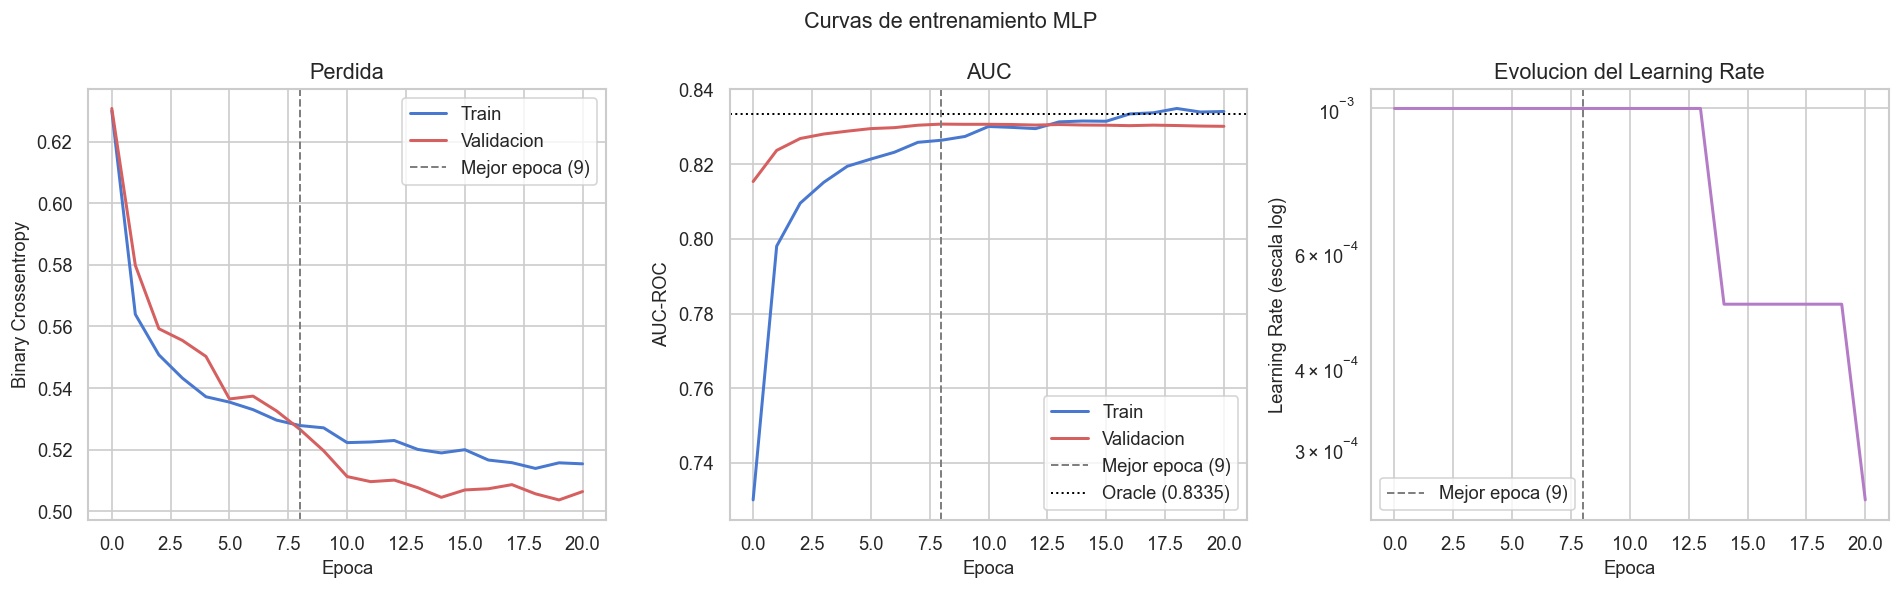

Gap train-val AUC en mejor epoca: 0.0042
Sin overfitting significativo.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Loss ─────────────────────────────────────────────────────────────
axes[0].plot(history.history['loss'],     color='#4878CF', linewidth=1.8, label='Train')
axes[0].plot(history.history['val_loss'], color='#D65F5F', linewidth=1.8, label='Validacion')
axes[0].axvline(best_epoch-1, color='gray', linestyle='--', linewidth=1.2,
                label=f'Mejor epoca ({best_epoch})')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].set_title('Perdida')
axes[0].legend()

# ── Panel 2: AUC ──────────────────────────────────────────────────────────────
axes[1].plot(history.history['auc'],     color='#4878CF', linewidth=1.8, label='Train')
axes[1].plot(history.history['val_auc'], color='#D65F5F', linewidth=1.8, label='Validacion')
axes[1].axvline(best_epoch-1, color='gray', linestyle='--', linewidth=1.2,
                label=f'Mejor epoca ({best_epoch})')
axes[1].axhline(ORACLE_AUC, color='black', linestyle=':', linewidth=1.2,
                label=f'Oracle ({ORACLE_AUC})')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC')
axes[1].legend()

# ── Panel 3: Learning Rate ────────────────────────────────────────────────────
axes[2].semilogy(lr_history, color='#B47CC7', linewidth=1.8)
axes[2].axvline(best_epoch-1, color='gray', linestyle='--', linewidth=1.2,
                label=f'Mejor epoca ({best_epoch})')
axes[2].set_xlabel('Epoca')
axes[2].set_ylabel('Learning Rate (escala log)')
axes[2].set_title('Evolucion del Learning Rate')
axes[2].legend()

plt.suptitle('Curvas de entrenamiento MLP', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '16_mlp_training_curves.png'), bbox_inches='tight')
plt.show()

# Diagnostico de overfitting
gap_auc = (max(history.history['auc']) - best_val_auc)
print(f"Gap train-val AUC en mejor epoca: {gap_auc:.4f}")
if gap_auc < 0.02:
    print("Sin overfitting significativo.")
elif gap_auc < 0.05:
    print("Leve overfitting — dentro de lo esperado con Dropout y BN.")
else:
    print("Overfitting notable — considerar mas regularizacion.")

---
## 6.6 Ajuste de umbral sobre validación

Procedimiento requerido por el enunciado:
1. Calcular probabilidades sobre el conjunto de **validación** (no test)
2. Barrer umbrales [0.1, 0.9] con paso 0.01
3. Seleccionar el que maximiza F1
4. Aplicar ese umbral **una sola vez** sobre test

Optimizar el umbral sobre test sería data leakage.

Umbral optimo (max F1 en validacion): 0.70
F1 en validacion con ese umbral:      0.5562
(El umbral por defecto 0.50 da F1:    0.5310)


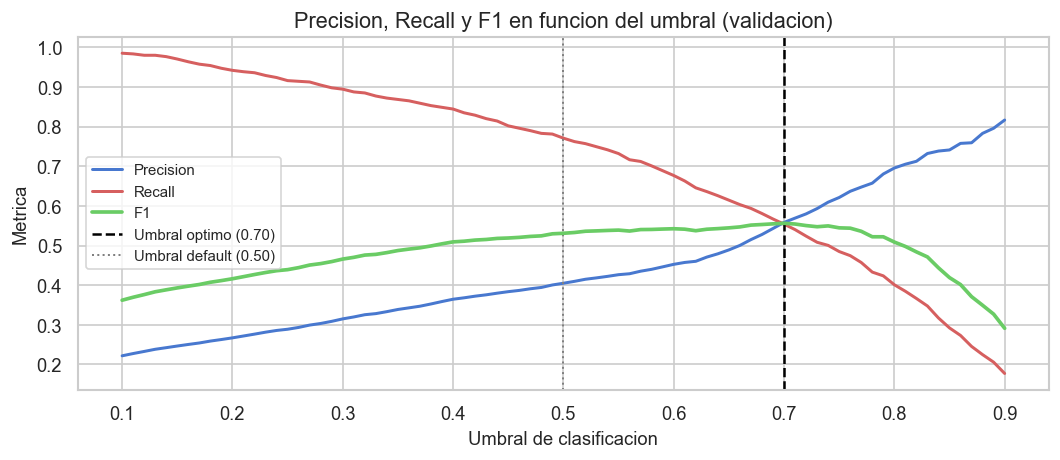

In [7]:
y_proba_val = mlp.predict(X_val, verbose=0).ravel()

thresholds  = np.arange(0.10, 0.91, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    precisions.append(precision_score(y_val, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_val, y_pred_t, zero_division=0))

THRESHOLD_MLP = float(thresholds[np.argmax(f1s)])
best_f1_val   = max(f1s)

print(f"Umbral optimo (max F1 en validacion): {THRESHOLD_MLP:.2f}")
print(f"F1 en validacion con ese umbral:      {best_f1_val:.4f}")
print(f"(El umbral por defecto 0.50 da F1:    {f1s[list(thresholds).index(min(thresholds, key=lambda x: abs(x-0.5)))]:.4f})")

# Grafico de metricas vs umbral
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions, color='#4878CF', linewidth=1.8, label='Precision')
ax.plot(thresholds, recalls,    color='#D65F5F', linewidth=1.8, label='Recall')
ax.plot(thresholds, f1s,        color='#6ACC65', linewidth=2.2, label='F1', zorder=5)
ax.axvline(THRESHOLD_MLP, color='black', linestyle='--', linewidth=1.5,
           label=f'Umbral optimo ({THRESHOLD_MLP:.2f})')
ax.axvline(0.50, color='gray', linestyle=':', linewidth=1.2, label='Umbral default (0.50)')
ax.set_xlabel('Umbral de clasificacion')
ax.set_ylabel('Metrica')
ax.set_title('Precision, Recall y F1 en funcion del umbral (validacion)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '17_mlp_threshold_analysis.png'), bbox_inches='tight')
plt.show()

---
## 6.7 Comparación MLP vs modelos clásicos en validación

Comparación directa antes de abrir el test.
Usamos X_val para la MLP y CV sobre X_train para los clásicos.

In [8]:
# Cargar probabilidades clásicas sobre test y recalcular en val
# Para comparacion justa usamos métricas de validacion de ambos lados
probas_classical = joblib.load(os.path.join(DATA_PROC, 'probas_classical.joblib'))

# Métricas MLP en validacion
y_pred_val_mlp = (y_proba_val >= THRESHOLD_MLP).astype(int)
mlp_val_metrics = {
    'modelo':    'MLP',
    'f1_val':    f1_score(y_val, y_pred_val_mlp, zero_division=0),
    'auc_val':   roc_auc_score(y_val, y_proba_val),
    'brier_val': brier_score_loss(y_val, y_proba_val),
    'threshold': THRESHOLD_MLP,
}

# Métricas clásicos en CV (ya calculadas en nb05, las cargamos)
import csv
cv_path = os.path.join(ROOT, 'outputs', 'tables', 'cv_results.csv')
df_cv   = pd.read_csv(cv_path)

print("=== Comparacion MLP vs Modelos Clasicos ===")
print()
print(f"{'Modelo':<22} {'F1':>8} {'AUC':>8} {'Brier':>8} {'Umbral':>8}")
print("-" * 56)
for _, row in df_cv.iterrows():
    f1_v  = float(row['f1_cv'].split(' ')[0])
    auc_v = float(row['auc_cv'].split(' ')[0])
    print(f"  {row['modelo']:<20} {f1_v:>8.4f} {auc_v:>8.4f} {row['brier']:>8.4f} {'0.50':>8}")
print(f"  {'MLP':<20} {mlp_val_metrics['f1_val']:>8.4f} {mlp_val_metrics['auc_val']:>8.4f}"
      f" {mlp_val_metrics['brier_val']:>8.4f} {THRESHOLD_MLP:>8.2f}")
print()
print(f"Oracle AUC (techo): {ORACLE_AUC}")

=== Comparacion MLP vs Modelos Clasicos ===

Modelo                       F1      AUC    Brier   Umbral
--------------------------------------------------------
  LogReg (baseline)      0.5413   0.8315   0.1659     0.50
  Random Forest          0.5426   0.8230   0.1499     0.50
  XGBoost                0.5374   0.8255   0.1631     0.50
  LightGBM               0.5390   0.8230   0.1549     0.50
  MLP                    0.5562   0.8307   0.1714     0.70

Oracle AUC (techo): 0.8335


---
## 6.8 Guardado de artefactos

In [9]:
# Probabilidades sobre test (umbral se aplica en nb07)
y_proba_test_mlp = mlp.predict(X_test, verbose=0).ravel()
np.save(os.path.join(DATA_PROC, 'probas_mlp.npy'), y_proba_test_mlp)

# Umbral optimo y métricas de validacion
mlp_meta = {
    'threshold_optimal': THRESHOLD_MLP,
    'best_val_auc':      float(best_val_auc),
    'best_epoch':        int(best_epoch),
    'total_epochs':      int(total_epochs),
    'val_f1':            float(mlp_val_metrics['f1_val']),
    'val_brier':         float(mlp_val_metrics['brier_val']),
    'n_params':          int(mlp.count_params()),
}
with open(os.path.join(DATA_PROC, 'mlp_meta.json'), 'w') as f:
    json.dump(mlp_meta, f, indent=2)

print("Artefactos guardados:")
for fname in ['mlp_best.keras']:
    fpath = os.path.join(MODELS, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  models/{fname:<25} {size:>8.1f} KB")
for fname in ['probas_mlp.npy', 'mlp_meta.json']:
    fpath = os.path.join(DATA_PROC, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  data/processed/{fname:<20} {size:>8.1f} KB")

print()
print(f"Resumen MLP:")
print(f"  Parametros:      {mlp_meta['n_params']:,}")
print(f"  Mejor epoca:     {best_epoch} / {total_epochs}")
print(f"  Val AUC:         {best_val_auc:.4f}  ({100*best_val_auc/ORACLE_AUC:.1f}% del Oracle)")
print(f"  Umbral optimo:   {THRESHOLD_MLP:.2f}")
print()
print("Listo para Notebook 07 - Evaluacion Final")

Artefactos guardados:
  models/mlp_best.keras               268.9 KB
  data/processed/probas_mlp.npy           39.2 KB
  data/processed/mlp_meta.json             0.2 KB

Resumen MLP:
  Parametros:      17,665
  Mejor epoca:     9 / 21
  Val AUC:         0.8307  (99.7% del Oracle)
  Umbral optimo:   0.70

Listo para Notebook 07 - Evaluacion Final
